# 02 — Credit Risk Dataset EDA

**Dataset:** Give Me Some Credit (`cs-training.csv`)
**Goal:** Understand default patterns, missing data, and outliers before modeling
probability of default (credit risk).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 40)

df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
df.shape

(150000, 11)

In [2]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1. Data quality checks

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing % :")
print((df.isnull().mean()*100).round(2))

Missing values per column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Missing % :
SeriousDlqin2yrs                         0.00
RevolvingUtilizationOfUnsecuredLines     0.00
age                                      0.00
NumberOfTime30-59DaysPastDueNotWorse     0.00
DebtRatio                                0.00
MonthlyIncome                           19.82
NumberOfOpenCreditLinesAndLoans          0.00
NumberOfTimes90DaysLate                  0.00
NumberRealEstateLoansOrLines             0.00
NumberOfTime60-89DaysPastDu

**Finding:** `MonthlyIncome` is missing for ~19.8% of rows, `NumberOfDependents`
for ~2.6%. Both are plausible MNAR/MAR situations (people under-report income).
We'll impute `MonthlyIncome` with the median within age/utilization bands and
`NumberOfDependents` with 0 (most common value) during preprocessing, and add
`_was_missing` flag columns so the model can learn from missingness itself.

## 2. Target distribution

In [4]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
default_rate = df['SeriousDlqin2yrs'].mean() * 100
print(target_counts)
print(f"\nDefault rate: {default_rate:.2f}%")

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%


**Finding:** ~6.68% of customers defaulted (had a serious delinquency within 2
years). This is a moderate imbalance — much less extreme than the fraud dataset
(0.17%) but still needs Precision/Recall/F1/ROC-AUC evaluation rather than
accuracy alone.

## 3. Outlier / data-integrity checks

In [5]:
df[['age','RevolvingUtilizationOfUnsecuredLines','DebtRatio',
    'NumberOfTime30-59DaysPastDueNotWorse','NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse']].describe()

,age,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,52.295207,6.048438,353.005076,0.421033,0.265973,0.240387
std,14.771866,249.755371,2037.818523,4.192781,4.169304,4.155179
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.029867,0.175074,0.000000,0.000000,0.000000
50%,52.000000,0.154181,0.366508,0.000000,0.000000,0.000000
75%,63.000000,0.559046,0.868254,0.000000,0.000000,0.000000
max,109.000000,50708.000000,329664.000000,98.000000,98.000000,98.000000


**Finding — known data quality issues in this dataset (documented publicly):**
- `age` has a minimum of 0, which is invalid for a credit applicant — we'll floor
  this at 18 or treat as missing.
- `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` have extreme max values
  (utilization > 1 should be rare/capped; some DebtRatio values exceed 100000,
  likely a data entry artifact where an income value ended up here). We'll cap
  these at a high percentile (e.g. 99.5th) during preprocessing rather than drop
  rows, to avoid losing genuine high-risk signal.
- The `NumberOfTime*PastDue*` columns contain sentinel values of 96/98 for a
  small number of rows — a known quirk of this dataset (codes, not real counts).
  We'll cap these at a reasonable max (e.g. 20) during preprocessing.

In [6]:
print("Rows with age == 0:", (df['age']==0).sum())
print("Rows with 30-59 days past due >= 96:", (df['NumberOfTime30-59DaysPastDueNotWorse']>=96).sum())
print("Rows with utilization > 2:", (df['RevolvingUtilizationOfUnsecuredLines']>2).sum())
print("Max DebtRatio:", df['DebtRatio'].max())

Rows with age == 0: 1
Rows with 30-59 days past due >= 96: 269
Rows with utilization > 2: 371
Max DebtRatio: 329664.0


## 4. Default rate by key risk drivers

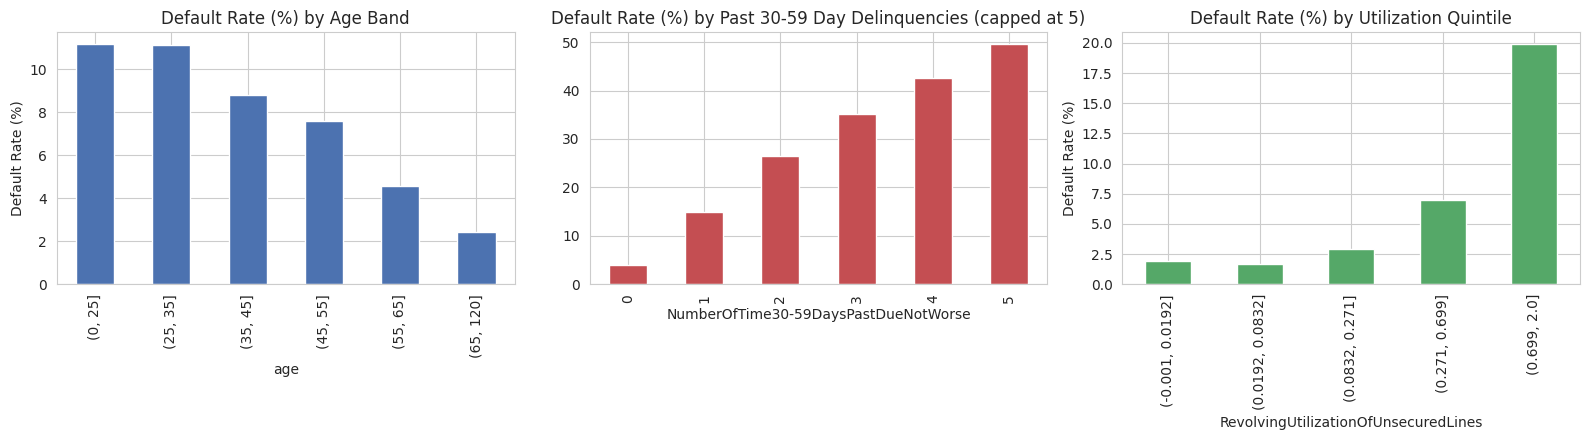

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Age bands
age_bins = pd.cut(df['age'], bins=[0,25,35,45,55,65,120])
df.groupby(age_bins, observed=True)['SeriousDlqin2yrs'].mean().mul(100).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Default Rate (%) by Age Band')
axes[0].set_ylabel('Default Rate (%)')

# Delinquency history
df.groupby(df['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=5))['SeriousDlqin2yrs'].mean().mul(100).plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Default Rate (%) by Past 30-59 Day Delinquencies (capped at 5)')

# Utilization quartiles
util_q = pd.qcut(df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2), 5, duplicates='drop')
df.groupby(util_q, observed=True)['SeriousDlqin2yrs'].mean().mul(100).plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Default Rate (%) by Utilization Quintile')
axes[2].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.savefig('../data/processed/credit_eda_summary.png', dpi=120)
plt.show()

**Finding:** Clear, interpretable risk drivers:
- **Younger borrowers default more** — default rate drops steadily with age.
- **Prior delinquency is the strongest signal** — even one 30-59 day late payment
  roughly doubles default rate; multiple delinquencies push it much higher.
- **Higher credit utilization strongly predicts default** — the top utilization
  quintile defaults far more often than the bottom.

These line up well with real underwriting intuition and will make for strong,
explainable SHAP narratives later.

## Summary of EDA findings

1. **Missing data**: `MonthlyIncome` (~19.8%) and `NumberOfDependents` (~2.6%) — impute + add missingness flags.
2. **Target**: 6.68% default rate — moderate imbalance, use Precision/Recall/F1/ROC-AUC.
3. **Data quality issues**: invalid `age=0`, extreme outliers in `DebtRatio` / utilization, sentinel codes (96/98) in delinquency counts — all need capping/cleaning, not row deletion.
4. **Strongest risk drivers**: prior delinquency count, credit utilization, and age — consistent with real-world underwriting and will anchor the SHAP explanations.

**Next step:** shared preprocessing pipeline (`src/data/preprocessing.py`) handling both datasets, then feature engineering and train/test split.